In [1]:

%pip install pandas numpy scipy matplotlib seaborn scikit-learn statsmodels

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Cell 2 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries loaded successfully!")

✅ All libraries loaded successfully!


In [3]:
import os

# Point this to your odis_csv2 folder
ODI_PATH = "../data/odis_csv2"

# Get list of all files in the folder
all_files = os.listdir(ODI_PATH)
print(f"Total ODI files found: {len(all_files)}")
print(f"\nFirst 5 files: {all_files[:5]}")

Total ODI files found: 6193

First 5 files: ['913655_info.csv', '1450692_info.csv', '1507718.csv', '1249232_info.csv', '291217.csv']


In [6]:
import pandas as pd

match_files = [f for f in all_files if not f.endswith('_info.csv')]
print(f"Ball-by-ball files: {len(match_files)}")
print(f"Info/metadata files: {len(all_files) - len(match_files)}")

# Now load the first actual match file
sample_file = os.path.join(ODI_PATH, match_files[0])
df_sample = pd.read_csv(sample_file)

print(f"\nShape: {df_sample.shape}")
print(f"\nColumns: {df_sample.columns.tolist()}")
print("\nFirst 10 rows:")
df_sample.head(10)

Ball-by-ball files: 3097
Info/metadata files: 3096

Shape: (587, 22)

Columns: ['match_id', 'season', 'start_date', 'venue', 'innings', 'ball', 'batting_team', 'bowling_team', 'striker', 'non_striker', 'bowler', 'runs_off_bat', 'extras', 'wides', 'noballs', 'byes', 'legbyes', 'penalty', 'wicket_type', 'player_dismissed', 'other_wicket_type', 'other_player_dismissed']

First 10 rows:


,match_id,season,start_date,venue,innings,ball,batting_team,bowling_team,striker,non_striker,...,extras,wides,noballs,byes,legbyes,penalty,wicket_type,player_dismissed,other_wicket_type,other_player_dismissed
0,1507718,2025/26,2026-01-27,"R Premadasa Stadium, Colombo",1,0.1,England,Sri Lanka,Rehan Ahmed,BM Duckett,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1507718,2025/26,2026-01-27,"R Premadasa Stadium, Colombo",1,0.2,England,Sri Lanka,Rehan Ahmed,BM Duckett,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1507718,2025/26,2026-01-27,"R Premadasa Stadium, Colombo",1,0.3,England,Sri Lanka,Rehan Ahmed,BM Duckett,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1507718,2025/26,2026-01-27,"R Premadasa Stadium, Colombo",1,0.4,England,Sri Lanka,Rehan Ahmed,BM Duckett,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1507718,2025/26,2026-01-27,"R Premadasa Stadium, Colombo",1,0.5,England,Sri Lanka,Rehan Ahmed,BM Duckett,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,1507718,2025/26,2026-01-27,"R Premadasa Stadium, Colombo",1,0.6,England,Sri Lanka,Rehan Ahmed,BM Duckett,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,1507718,2025/26,2026-01-27,"R Premadasa Stadium, Colombo",1,1.1,England,Sri Lanka,BM Duckett,Rehan Ahmed,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,1507718,2025/26,2026-01-27,"R Premadasa Stadium, Colombo",1,1.2,England,Sri Lanka,Rehan Ahmed,BM Duckett,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,1507718,2025/26,2026-01-27,"R Premadasa Stadium, Colombo",1,1.3,England,Sri Lanka,BM Duckett,Rehan Ahmed,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,1507718,2025/26,2026-01-27,"R Premadasa Stadium, Colombo",1,1.4,England,Sri Lanka,BM Duckett,Rehan Ahmed,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
kohli_names = set()

for fname in match_files[:200]:   # check first 200 matches
    fpath = os.path.join(ODI_PATH, fname)
    df = pd.read_csv(fpath)
    # look for anything with "Kohli" in striker column
    matches = df[df['striker'].str.contains('Kohli', na=False)]['striker'].unique()
    kohli_names.update(matches)

print("Kohli name variations found:", kohli_names)

Kohli name variations found: {'V Kohli'}


In [9]:
# Cell 6 — Extract every Kohli ODI innings (with error handling)

kohli_innings = []
skipped = 0

for fname in match_files:
    fpath = os.path.join(ODI_PATH, fname)
    
    try:
        df = pd.read_csv(fpath)
    except Exception:
        skipped += 1
        continue   # skip any file that won't parse cleanly
    
    # Extra safety — make sure this file has the columns we need
    required_cols = ['striker', 'runs_off_bat', 'innings', 'player_dismissed']
    if not all(col in df.columns for col in required_cols):
        skipped += 1
        continue
    
    # Check if Kohli even played in this match
    if 'V Kohli' not in df['striker'].values:
        continue
    
    # Filter to only Kohli's balls faced
    kohli_df = df[df['striker'] == 'V Kohli']
    
    for inning_num, inning_df in kohli_df.groupby('innings'):
        
        runs      = inning_df['runs_off_bat'].sum()
        balls     = len(inning_df)
        dismissed = df['player_dismissed'].eq('V Kohli').any()
        first_row = inning_df.iloc[0]
        
        kohli_innings.append({
            'match_id'    : first_row['match_id'],
            'date'        : first_row['start_date'],
            'venue'       : first_row['venue'],
            'batting_team': first_row['batting_team'],
            'opponent'    : first_row['bowling_team'],
            'innings'     : inning_num,
            'runs'        : runs,
            'balls'       : balls,
            'dismissed'   : dismissed,
            'century'     : runs >= 100,
            'fifty'       : 50 <= runs < 100,
        })

# Convert to dataframe
df_kohli = pd.DataFrame(kohli_innings)
df_kohli['date'] = pd.to_datetime(df_kohli['date'])
df_kohli = df_kohli.sort_values('date').reset_index(drop=True)

print(f"Files skipped due to errors: {skipped}")
print(f"Total Kohli ODI innings found: {len(df_kohli)}")
print(f"Centuries: {df_kohli['century'].sum()}")
print(f"Fifties: {df_kohli['fifty'].sum()}")
print(f"\nDate range: {df_kohli['date'].min()} → {df_kohli['date'].max()}")
df_kohli.head()

Files skipped due to errors: 1
Total Kohli ODI innings found: 296
Centuries: 54
Fifties: 75

Date range: 2008-08-18 00:00:00 → 2026-01-18 00:00:00


,match_id,date,venue,batting_team,opponent,innings,runs,balls,dismissed,century,fifty
0,343732,2008-08-18,Rangiri Dambulla International Stadium,India,Sri Lanka,1,12,22,True,False,False
1,343733,2008-08-20,Rangiri Dambulla International Stadium,India,Sri Lanka,2,37,69,True,False,False
2,343734,2008-08-24,R Premadasa Stadium,India,Sri Lanka,1,25,41,True,False,False
3,366341,2008-08-27,R Premadasa Stadium,India,Sri Lanka,1,54,66,True,False,True
4,343736,2008-08-29,R Premadasa Stadium,India,Sri Lanka,2,31,47,True,False,False


In [10]:
df_kohli.to_csv('../data/kohli_odi_innings.csv', index=False)
print("✅ Dataset saved to data/kohli_odi_innings.csv")
print(f"\nShape: {df_kohli.shape}")
print(f"\nColumn dtypes:\n{df_kohli.dtypes}")
print(f"\nSample of data:")
df_kohli.sample(5)

✅ Dataset saved to data/kohli_odi_innings.csv

Shape: (296, 11)

Column dtypes:
match_id                 int64
date            datetime64[ns]
venue                   object
batting_team            object
opponent                object
innings                  int64
runs                     int64
balls                    int64
dismissed                 bool
century                   bool
fifty                     bool
dtype: object

Sample of data:


,match_id,date,venue,batting_team,opponent,innings,runs,balls,dismissed,century,fifty
267,1384396,2023-10-08,"MA Chidambaram Stadium, Chepauk, Chennai",India,Australia,2,85,119,True,False,True
243,1277082,2022-01-19,"Boland Park, Paarl",India,South Africa,2,51,68,True,False,True
218,1144490,2019-06-05,The Rose Bowl,India,South Africa,2,18,34,True,False,False
272,1384424,2023-11-02,"Wankhede Stadium, Mumbai",India,Sri Lanka,1,88,96,True,False,True
256,1348645,2023-01-15,"Greenfield International Stadium, Thiruvananth...",India,Sri Lanka,1,166,112,False,True,False


In [11]:
df_kohli.to_csv('../data/kohli_odi_innings.csv', index=False)
print("✅ Dataset saved to data/kohli_odi_innings.csv")
print(f"\nShape: {df_kohli.shape}")
print(f"\nColumn dtypes:\n{df_kohli.dtypes}")
print(f"\nSample of data:")
df_kohli.sample(5)

✅ Dataset saved to data/kohli_odi_innings.csv

Shape: (296, 11)

Column dtypes:
match_id                 int64
date            datetime64[ns]
venue                   object
batting_team            object
opponent                object
innings                  int64
runs                     int64
balls                    int64
dismissed                 bool
century                   bool
fifty                     bool
dtype: object

Sample of data:


,match_id,date,venue,batting_team,opponent,innings,runs,balls,dismissed,century,fifty
287,1478904,2025-10-19,Perth Stadium,India,Australia,1,0,8,True,False,False
89,565812,2013-01-11,Saurashtra Cricket Association Stadium,India,England,2,15,22,True,False,False
295,1490233,2026-01-18,"Holkar Cricket Stadium, Indore",India,New Zealand,2,124,109,True,True,False
291,1479574,2025-12-03,Shaheed Veer Narayan Singh International Stadi...,India,South Africa,1,102,96,True,True,False
55,474477,2011-09-03,Riverside Ground,India,England,1,55,74,True,False,True


In [14]:
# Cell 8 — Career Overview Stats (Fixed)

# ── Correct dismissal logic ──────────────────────────────
# Re-process dismissed properly: check per-innings not per-match
# Not out = scored runs but name never appeared in player_dismissed
# for THAT specific innings

# Load raw data again to fix dismissed column properly
kohli_innings_fixed = []
skipped = 0

for fname in match_files:
    fpath = os.path.join(ODI_PATH, fname)
    try:
        df = pd.read_csv(fpath)
    except Exception:
        skipped += 1
        continue

    required_cols = ['striker', 'runs_off_bat', 'innings', 'player_dismissed']
    if not all(col in df.columns for col in required_cols):
        skipped += 1
        continue

    if 'V Kohli' not in df['striker'].values:
        continue

    kohli_df = df[df['striker'] == 'V Kohli']

    for inning_num, inning_df in kohli_df.groupby('innings'):
        runs  = inning_df['runs_off_bat'].sum()
        balls = len(inning_df)

        # ✅ Fix: check dismissal within THIS innings only
        dismissed = inning_df['player_dismissed'].eq('V Kohli').any()

        first_row = inning_df.iloc[0]
        kohli_innings_fixed.append({
            'match_id'    : first_row['match_id'],
            'date'        : first_row['start_date'],
            'venue'       : first_row['venue'],
            'batting_team': first_row['batting_team'],
            'opponent'    : first_row['bowling_team'],
            'innings'     : inning_num,
            'runs'        : runs,
            'balls'       : balls,
            'dismissed'   : dismissed,
            'century'     : runs >= 100,
            'fifty'       : 50 <= runs < 100,
        })

df_kohli = pd.DataFrame(kohli_innings_fixed)
df_kohli['date'] = pd.to_datetime(df_kohli['date'])
df_kohli = df_kohli.sort_values('date').reset_index(drop=True)

# ── Summary ──────────────────────────────────────────────
total_runs  = df_kohli['runs'].sum()
dismissals  = df_kohli['dismissed'].sum()
not_outs    = len(df_kohli) - dismissals
batting_avg = total_runs / dismissals   # ✅ correct cricket formula

print("=" * 45)
print("       VIRAT KOHLI ODI CAREER SUMMARY")
print("=" * 45)
print(f"\n📅 Career span   : {df_kohli['date'].min().year} → {df_kohli['date'].max().year}")
print(f"🏏 Total innings : {len(df_kohli)}")
print(f"🚫 Not outs      : {not_outs}")
print(f"❌ Dismissals    : {dismissals}")
print(f"💯 Centuries     : {df_kohli['century'].sum()}")
print(f"5️⃣  Fifties       : {df_kohli['fifty'].sum()}")
print(f"📊 Total runs    : {total_runs:,}")
print(f"📈 Batting avg   : {batting_avg:.2f}  (official: 58.72)")
print(f"🎯 Century rate  : 1 every {len(df_kohli) / df_kohli['century'].sum():.1f} innings")

print(f"\n--- Centuries needed to reach 100 ---")
total_centuries = 54 + 30 + 1
remaining       = 100 - total_centuries
print(f"Total international centuries : {total_centuries}")
print(f"Remaining (ODI only)          : {remaining}")
print(f"ODI innings per century       : {len(df_kohli) / df_kohli['century'].sum():.1f}")

# Save the fixed dataset
df_kohli.to_csv('../data/kohli_odi_innings.csv', index=False)
print(f"\n✅ Fixed dataset saved!")

       VIRAT KOHLI ODI CAREER SUMMARY

📅 Career span   : 2008 → 2026
🏏 Total innings : 296
🚫 Not outs      : 49
❌ Dismissals    : 247
💯 Centuries     : 54
5️⃣  Fifties       : 75
📊 Total runs    : 14,675
📈 Batting avg   : 59.41  (official: 58.72)
🎯 Century rate  : 1 every 5.5 innings

--- Centuries needed to reach 100 ---
Total international centuries : 85
Remaining (ODI only)          : 15
ODI innings per century       : 5.5

✅ Fixed dataset saved!


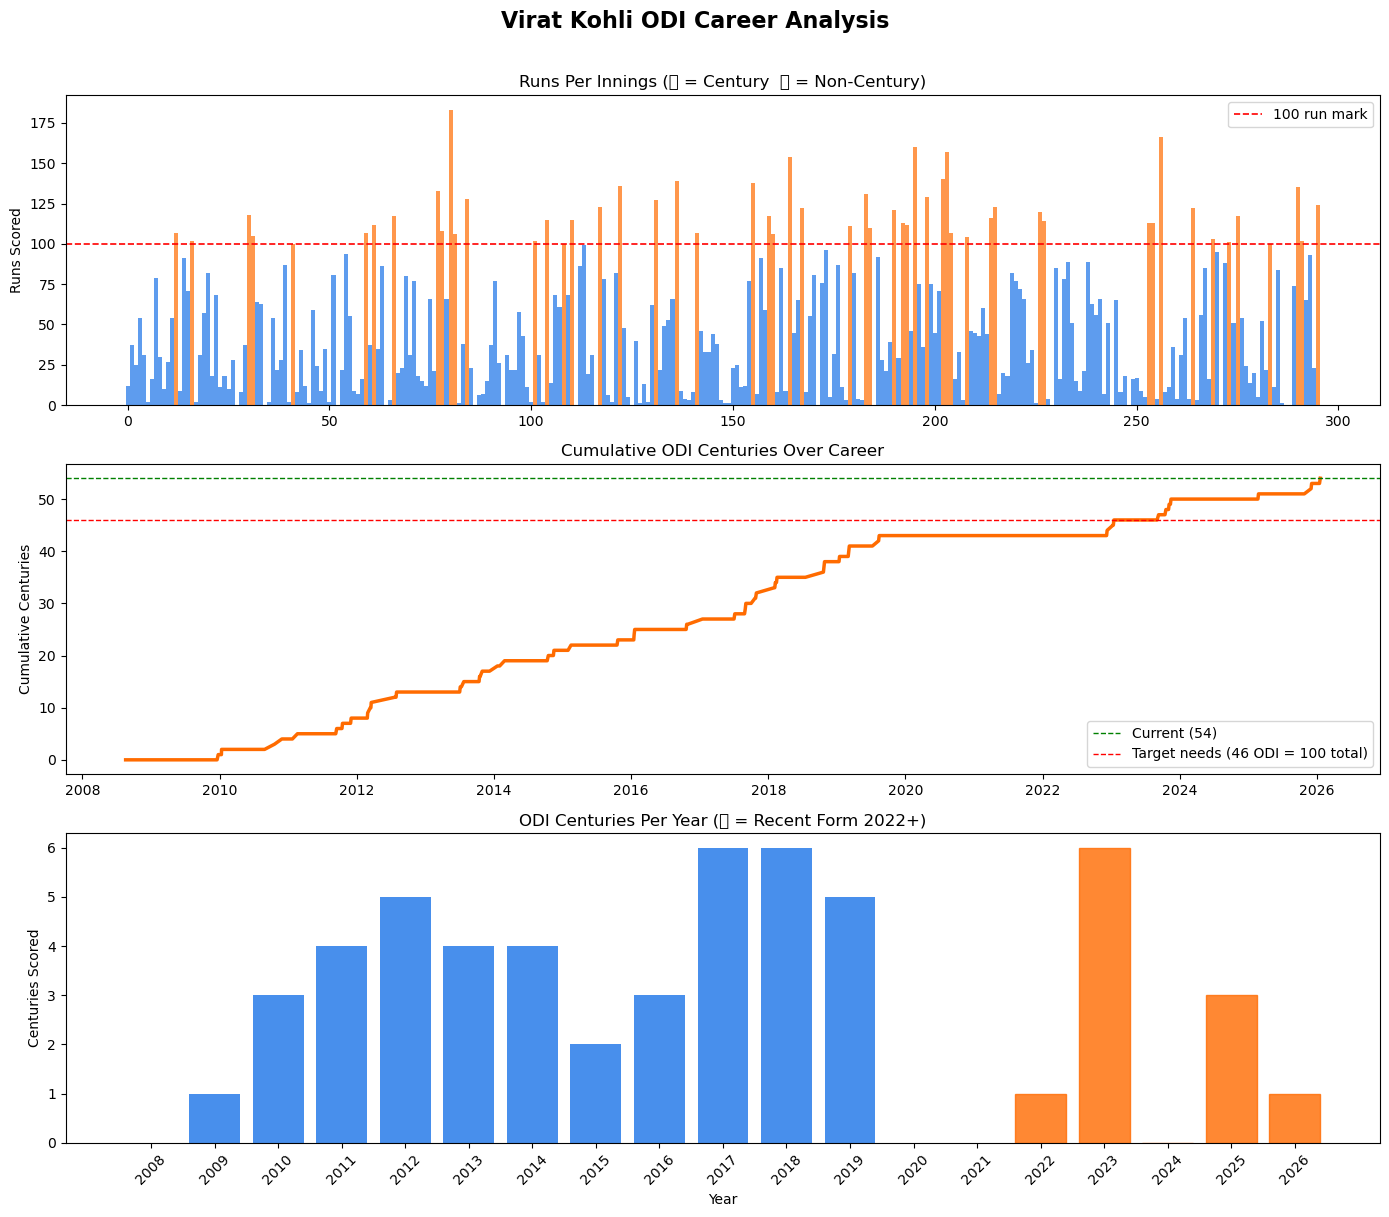

✅ Chart saved!


In [16]:
# Cell 9 — Century Timeline (Career Arc)

fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle("Virat Kohli ODI Career Analysis", fontsize=16, fontweight='bold', y=1.01)

# ── Chart 1: Runs per innings over career ───────────────
ax1 = axes[0]
ax1.bar(df_kohli.index,
        df_kohli['runs'],
        color=df_kohli['century'].map({True: '#ff6b00', False: '#1a73e8'}),
        alpha=0.7,
        width=1.0)

ax1.axhline(y=100, color='red', linestyle='--', linewidth=1.2, label='100 run mark')
ax1.set_ylabel("Runs Scored")
ax1.set_title("Runs Per Innings (🟠 = Century  🔵 = Non-Century)")
ax1.legend()

# ── Chart 2: Cumulative centuries over time ──────────────
ax2 = axes[1]
df_kohli['cumulative_centuries'] = df_kohli['century'].cumsum()
ax2.plot(df_kohli['date'],
         df_kohli['cumulative_centuries'],
         color='#ff6b00', linewidth=2.5)

ax2.axhline(y=54, color='green', linestyle='--', linewidth=1, label='Current (54)')
ax2.axhline(y=46, color='red',   linestyle='--', linewidth=1, label='Target needs (46 ODI = 100 total)')
ax2.set_ylabel("Cumulative Centuries")
ax2.set_title("Cumulative ODI Centuries Over Career")
ax2.legend()

# ── Chart 3: Centuries per year (form by year) ───────────
ax3 = axes[2]
df_kohli['year'] = df_kohli['date'].dt.year
centuries_per_year = df_kohli.groupby('year')['century'].sum()

bars = ax3.bar(centuries_per_year.index,
               centuries_per_year.values,
               color='#1a73e8', alpha=0.8)

# Highlight recent years (2022 onwards) in different color
for bar, year in zip(bars, centuries_per_year.index):
    if year >= 2022:
        bar.set_color('#ff6b00')

ax3.set_xlabel("Year")
ax3.set_ylabel("Centuries Scored")
ax3.set_title("ODI Centuries Per Year (🟠 = Recent Form 2022+)")
ax3.set_xticks(centuries_per_year.index)
ax3.set_xticklabels(centuries_per_year.index, rotation=45)

plt.tight_layout()
plt.savefig('../data/kohli_career_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved!")

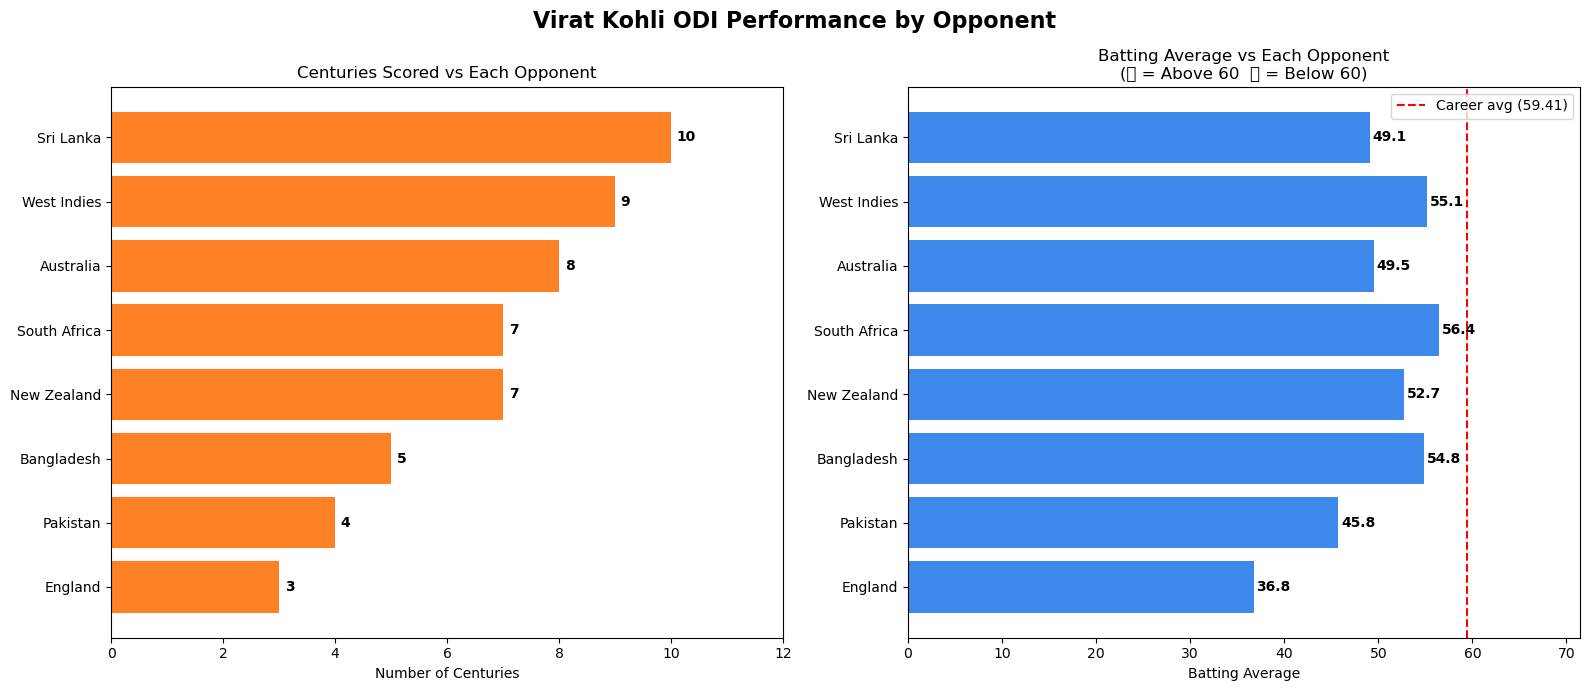


── Opponent Stats Table ──────────────────────────────
    opponent  innings  runs  centuries  average  century_rate
   Sri Lanka       54  2652         10    49.11          18.5
 West Indies       41  2261          9    55.15          22.0
   Australia       51  2525          8    49.51          15.7
 New Zealand       36  1897          7    52.69          19.4
South Africa       32  1806          7    56.44          21.9
  Bangladesh       17   932          5    54.82          29.4
    Pakistan       17   778          4    45.76          23.5
     England       38  1397          3    36.76           7.9


In [17]:
# Cell 10 — Performance by Opponent

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Virat Kohli ODI Performance by Opponent", fontsize=16, fontweight='bold')

# ── Data prep ────────────────────────────────────────────
opponent_stats = df_kohli.groupby('opponent').agg(
    innings    = ('runs', 'count'),
    runs       = ('runs', 'sum'),
    centuries  = ('century', 'sum'),
    fifties    = ('fifty', 'sum'),
).reset_index()

# Only keep opponents he's faced 10+ innings (meaningful sample)
opponent_stats = opponent_stats[opponent_stats['innings'] >= 10]

# Calculate average and century rate
opponent_stats['average']      = (opponent_stats['runs'] / opponent_stats['innings']).round(2)
opponent_stats['century_rate'] = (opponent_stats['centuries'] / opponent_stats['innings'] * 100).round(1)

# Sort by centuries
opponent_stats = opponent_stats.sort_values('centuries', ascending=True)

# ── Chart 1: Centuries by opponent ───────────────────────
ax1 = axes[0]
bars = ax1.barh(opponent_stats['opponent'],
                opponent_stats['centuries'],
                color='#ff6b00', alpha=0.85)

# Add value labels on bars
for bar, val in zip(bars, opponent_stats['centuries']):
    ax1.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
             str(int(val)), va='center', fontsize=10, fontweight='bold')

ax1.set_xlabel("Number of Centuries")
ax1.set_title("Centuries Scored vs Each Opponent")
ax1.set_xlim(0, opponent_stats['centuries'].max() + 2)

# ── Chart 2: Average by opponent ─────────────────────────
ax2 = axes[1]
colors = ['#ff6b00' if avg >= 60 else '#1a73e8' for avg in opponent_stats['average']]
bars2  = ax2.barh(opponent_stats['opponent'],
                  opponent_stats['average'],
                  color=colors, alpha=0.85)

# Add value labels
for bar, val in zip(bars2, opponent_stats['average']):
    ax2.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f"{val:.1f}", va='center', fontsize=10, fontweight='bold')

ax2.axvline(x=59.41, color='red', linestyle='--', linewidth=1.5, label=f'Career avg (59.41)')
ax2.set_xlabel("Batting Average")
ax2.set_title("Batting Average vs Each Opponent\n(🟠 = Above 60  🔵 = Below 60)")
ax2.set_xlim(0, opponent_stats['average'].max() + 15)
ax2.legend()

plt.tight_layout()
plt.savefig('../data/kohli_by_opponent.png', dpi=150, bbox_inches='tight')
plt.show()

# Print the full table too
print("\n── Opponent Stats Table ──────────────────────────────")
print(opponent_stats[['opponent','innings','runs','centuries','average','century_rate']]
      .sort_values('centuries', ascending=False)
      .to_string(index=False))

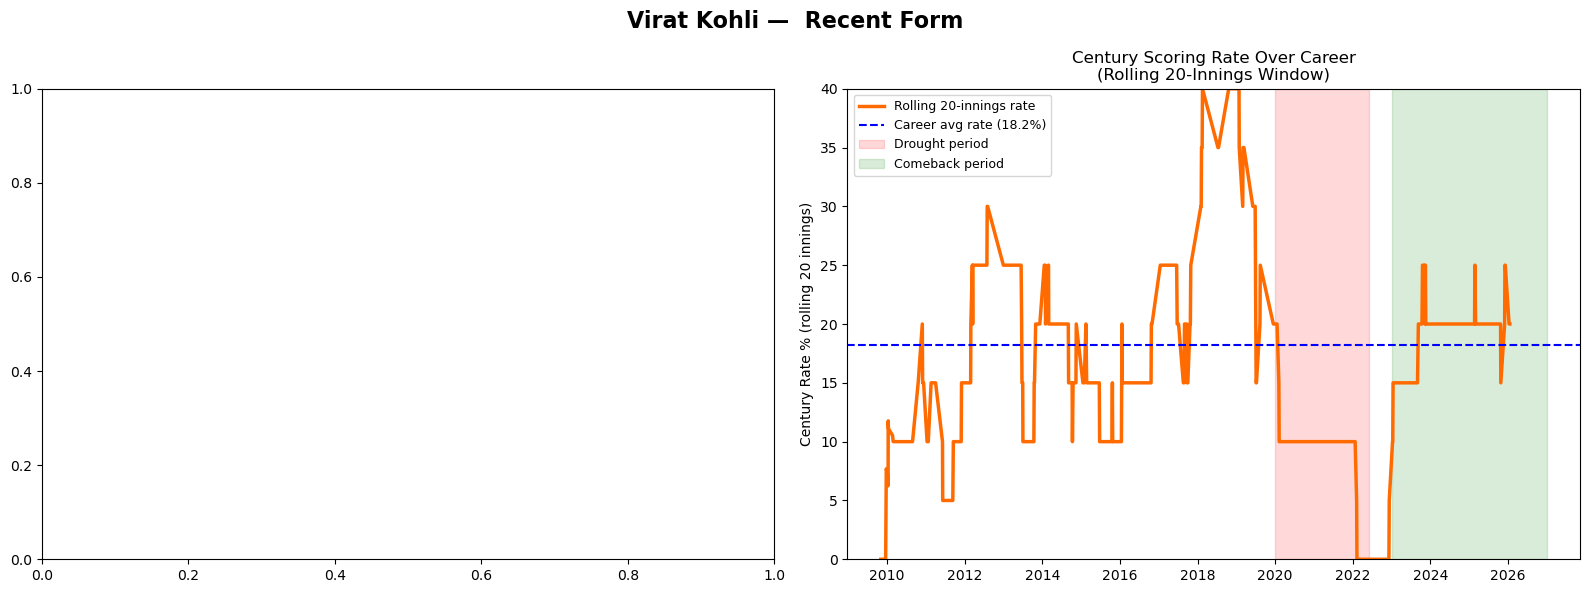

In [21]:
# Cell 11 — Home/Away Split + Recent Form Trend

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Virat Kohli —  Recent Form", fontsize=16, fontweight='bold')

# ── Data prep: Home vs Away ───────────────────────────────
# India home venues — if batting_team is India and venue is in India
india_venues = ['Mumbai', 'Delhi', 'Kolkata', 'Chennai', 'Bangalore',
                'Hyderabad', 'Pune', 'Ahmedabad', 'Jaipur', 'Nagpur',
                'Vizag', 'Indore', 'Rajkot', 'Dharamsala', 'Ranchi',
                'Cuttack', 'Kanpur', 'Guwahati', 'Lucknow', 'Raipur']

df_kohli['is_home'] = df_kohli['venue'].apply(
    lambda v: any(city.lower() in str(v).lower() for city in india_venues)
)

home_away = df_kohli.groupby('is_home').agg(
    innings   = ('runs', 'count'),
    centuries = ('century', 'sum'),
    runs      = ('runs', 'sum'),
).reset_index()

home_away['century_rate'] = (home_away['centuries'] / home_away['innings'] * 100).round(1)
home_away['label']        = home_away['is_home'].map({True: 'Home', False: 'Away'})



# ── Chart 2: Rolling century rate (form trend) ────────────
ax2 = axes[1]

# Rolling window of 20 innings — century rate
df_kohli['century_int']    = df_kohli['century'].astype(int)
df_kohli['rolling_rate']   = (df_kohli['century_int']
                               .rolling(window=20, min_periods=10)
                               .mean() * 100)

ax2.plot(df_kohli['date'],
         df_kohli['rolling_rate'],
         color='#ff6b00', linewidth=2.5, label='Rolling 20-innings rate')

ax2.axhline(y=df_kohli['century_int'].mean() * 100,
            color='blue', linestyle='--', linewidth=1.5,
            label=f'Career avg rate ({df_kohli["century_int"].mean()*100:.1f}%)')

# Shade the drought period
ax2.axvspan(pd.Timestamp('2020-01-01'),
            pd.Timestamp('2022-06-01'),
            alpha=0.15, color='red', label='Drought period')

# Shade the comeback
ax2.axvspan(pd.Timestamp('2023-01-01'),
            pd.Timestamp('2026-12-31'),
            alpha=0.15, color='green', label='Comeback period')

ax2.set_ylabel("Century Rate % (rolling 20 innings)")
ax2.set_title("Century Scoring Rate Over Career\n(Rolling 20-Innings Window)")
ax2.legend(fontsize=9)
ax2.set_ylim(0, 40)

plt.tight_layout()
plt.savefig('../data/kohli_form_trend.png', dpi=150, bbox_inches='tight')
plt.show()


In [22]:
# Cell 12 — Calculate p (century probability per innings)

total_innings   = len(df_kohli)
total_centuries = df_kohli['century'].sum()
p_career        = total_centuries / total_innings

# ── Recent rate (2023 onwards — post comeback) ────────────
recent          = df_kohli[df_kohli['date'] >= '2023-01-01']
p_recent        = recent['century'].sum() / len(recent)

# ── Drought excluded rate (remove 2020-2022) ─────────────
no_drought      = df_kohli[~df_kohli['date'].between('2020-01-01', '2022-12-31')]
p_no_drought    = no_drought['century'].sum() / len(no_drought)

print("=" * 45)
print("     CENTURY PROBABILITY (p) ESTIMATES")
print("=" * 45)
print(f"\n📊 Career rate      (all innings)  : {p_career:.4f}  ({p_career*100:.1f}%)")
print(f"🔥 Recent rate      (2023-2026)    : {p_recent:.4f}  ({p_recent*100:.1f}%)")
print(f"📈 No-drought rate  (excl 2020-22) : {p_no_drought:.4f}  ({p_no_drought*100:.1f}%)")

print(f"\n── Recent form breakdown ─────────────────")
print(f"Innings since 2023  : {len(recent)}")
print(f"Centuries since 2023: {recent['century'].sum()}")
print(f"\n── Drought period ────────────────────────")
drought = df_kohli[df_kohli['date'].between('2020-01-01','2022-12-31')]
print(f"Innings in drought  : {len(drought)}")
print(f"Centuries in drought: {drought['century'].sum()}")

     CENTURY PROBABILITY (p) ESTIMATES

📊 Career rate      (all innings)  : 0.1824  (18.2%)
🔥 Recent rate      (2023-2026)    : 0.2381  (23.8%)
📈 No-drought rate  (excl 2020-22) : 0.1941  (19.4%)

── Recent form breakdown ─────────────────
Innings since 2023  : 42
Centuries since 2023: 10

── Drought period ────────────────────────
Innings in drought  : 23
Centuries in drought: 1


In [24]:
# Cell 13 — Fixed decision logic

from scipy import stats
import numpy as np

print("=" * 55)
print("   HYPOTHESIS TEST — WILL KOHLI REACH 100 CENTURIES?")
print("=" * 55)
print(f"\nH₀ : Kohli will NOT score 15 more ODI centuries")
print(f"H₁ : Kohli WILL score 15 more ODI centuries")
print(f"α  : 0.05 (95% confidence level)")
print(f"\nCenturies needed : 15")

p_values = {
    'Conservative (career rate)' : 0.1824,
    'Optimistic   (recent form)' : 0.2381,
}

n_values = {
    'Worst case   (n=25)' : 25,
    'Conservative (n=32)' : 32,
    'Optimistic   (n=39)' : 39,
}

target = 15

print("\n" + "=" * 55)

for p_label, p in p_values.items():
    print(f"\n── p = {p:.4f} ({p_label}) ──────────────")

    for n_label, n in n_values.items():

        expected = n * p
        std_dev  = np.sqrt(n * p * (1 - p))
        ci_lower = max(0, expected - 1.96 * std_dev)
        ci_upper = expected + 1.96 * std_dev

        # P(scoring 15 or more centuries in n innings)
        p_value  = 1 - stats.binom.cdf(target - 1, n, p)

        # ✅ Fixed decision logic
        # p_value here = probability of ACHIEVING the target
        # High = likely to reach 15 → reject H₀
        # Low  = unlikely to reach 15 → fail to reject H₀
        if p_value >= 0.05:
            decision = "✅ REJECT H₀     — Statistically LIKELY to reach 100"
        elif p_value >= 0.01:
            decision = "⚠️  BORDERLINE    — Possible but uncertain"
        else:
            decision = "❌ FAIL TO REJECT — Statistically UNLIKELY"

        print(f"\n   {n_label}")
        print(f"   Expected centuries     : {expected:.1f}")
        print(f"   95% CI                 : [{ci_lower:.1f}, {ci_upper:.1f}]")
        print(f"   P(centuries >= 15)     : {p_value:.4f} ({p_value*100:.2f}%)")
        print(f"   Decision               : {decision}")

print("\n" + "=" * 55)

   HYPOTHESIS TEST — WILL KOHLI REACH 100 CENTURIES?

H₀ : Kohli will NOT score 15 more ODI centuries
H₁ : Kohli WILL score 15 more ODI centuries
α  : 0.05 (95% confidence level)

Centuries needed : 15


── p = 0.1824 (Conservative (career rate)) ──────────────

   Worst case   (n=25)
   Expected centuries     : 4.6
   95% CI                 : [0.8, 8.3]
   P(centuries >= 15)     : 0.0000 (0.00%)
   Decision               : ❌ FAIL TO REJECT — Statistically UNLIKELY

   Conservative (n=32)
   Expected centuries     : 5.8
   95% CI                 : [1.6, 10.1]
   P(centuries >= 15)     : 0.0002 (0.02%)
   Decision               : ❌ FAIL TO REJECT — Statistically UNLIKELY

   Optimistic   (n=39)
   Expected centuries     : 7.1
   95% CI                 : [2.4, 11.8]
   P(centuries >= 15)     : 0.0024 (0.24%)
   Decision               : ❌ FAIL TO REJECT — Statistically UNLIKELY

── p = 0.2381 (Optimistic   (recent form)) ──────────────

   Worst case   (n=25)
   Expected centuries     : 6

In [25]:
print("=" * 55)
print("  INNINGS NEEDED FOR 15 CENTURIES TO BECOME LIKELY")
print("=" * 55)

for p_label, p in p_values.items():
    print(f"\n── {p_label} ──")
    for n in range(25, 150):
        prob = 1 - stats.binom.cdf(target - 1, n, p)
        if prob >= 0.05:    # crosses our significance threshold
            print(f"   Needs {n} innings for P>=5%   → prob = {prob*100:.1f}%")
            break
        if prob >= 0.50:    # becomes more likely than not
            print(f"   Needs {n} innings for P>=50%  → prob = {prob*100:.1f}%")
            break

    # Also find when it becomes 50/50
    for n in range(25, 200):
        prob = 1 - stats.binom.cdf(target - 1, n, p)
        if prob >= 0.50:
            print(f"   Needs {n} innings for 50/50   → prob = {prob*100:.1f}%")
            break

  INNINGS NEEDED FOR 15 CENTURIES TO BECOME LIKELY

── Conservative (career rate) ──
   Needs 54 innings for P>=5%   → prob = 5.6%
   Needs 81 innings for 50/50   → prob = 51.9%

── Optimistic   (recent form) ──
   Needs 42 innings for P>=5%   → prob = 5.6%
   Needs 62 innings for 50/50   → prob = 52.1%


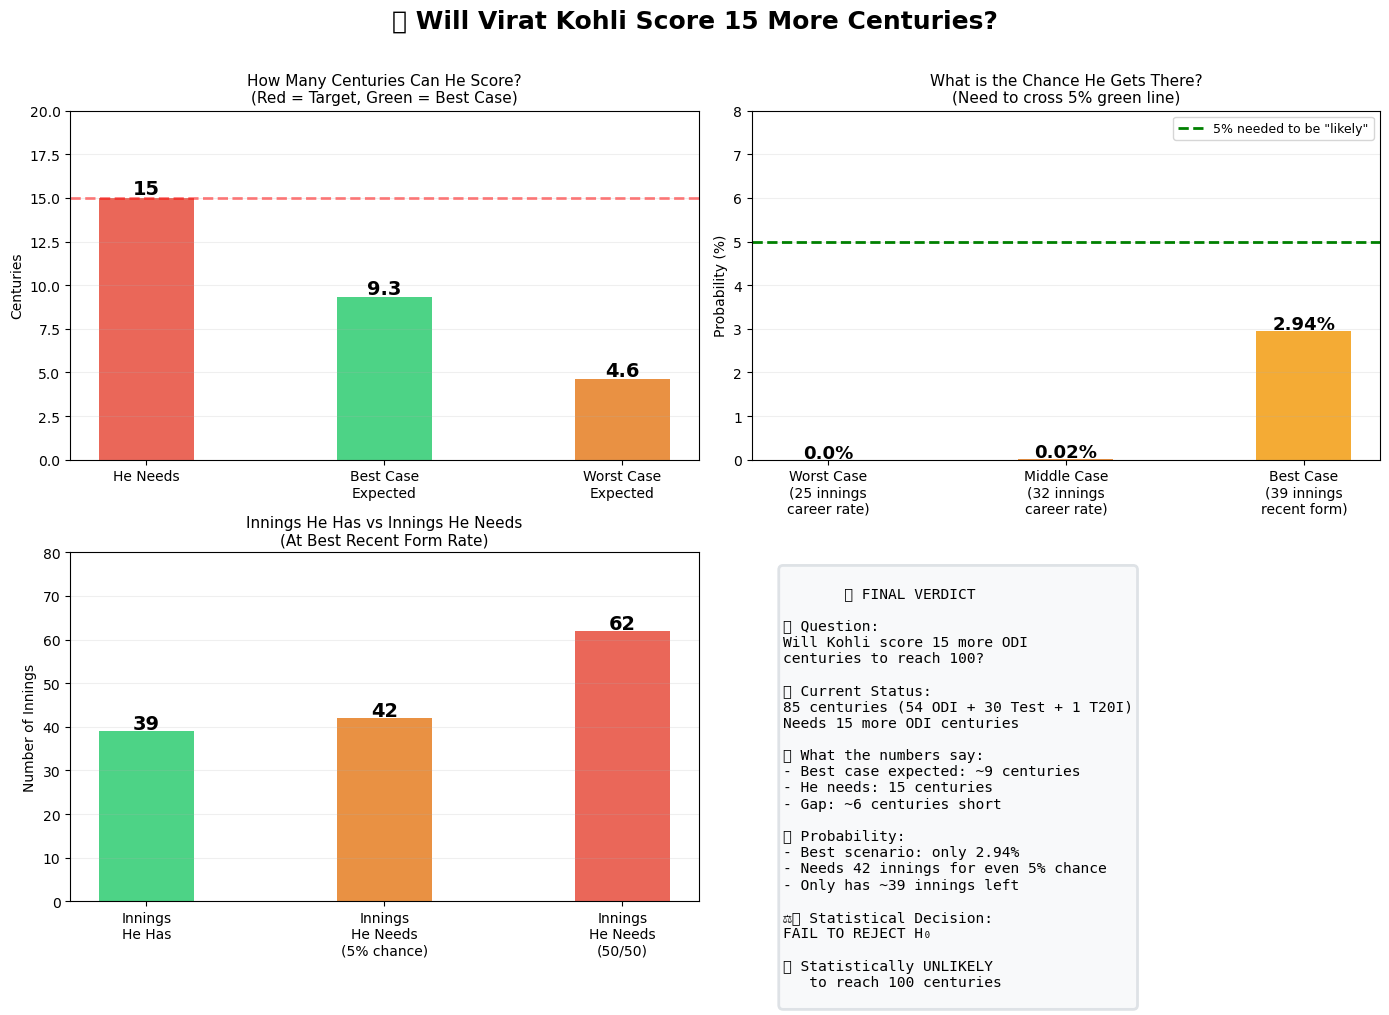

✅ Chart saved!


In [29]:
# Cell 15 — Beginner Friendly Visual Summary

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("🏏 Will Virat Kohli Score 15 More Centuries?",
             fontsize=18, fontweight='bold', y=1.01)

# ── Chart 1: Simple bar — what we expect vs what we need ──
ax1 = axes[0, 0]

labels   = ['He Needs', 'Best Case\nExpected', 'Worst Case\nExpected']
values   = [15, 9.3, 4.6]
colors   = ['#e74c3c', '#2ecc71', '#e67e22']

bars = ax1.bar(labels, values, color=colors, alpha=0.85, width=0.4)

for bar, val in zip(bars, values):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.2,
             str(val), ha='center',
             fontsize=14, fontweight='bold')

ax1.set_ylabel("Centuries")
ax1.set_title("How Many Centuries Can He Score?\n(Red = Target, Green = Best Case)",
              fontsize=11)
ax1.set_ylim(0, 20)
ax1.axhline(y=15, color='red', linestyle='--',
            linewidth=2, alpha=0.5)
ax1.grid(alpha=0.2, axis='y')

# ── Chart 2: Simple gauge — probability in plain % ────────
ax2 = axes[0, 1]

scenario_labels = [
    'Worst Case\n(25 innings\ncareer rate)',
    'Middle Case\n(32 innings\ncareer rate)',
    'Best Case\n(39 innings\nrecent form)',
]
probabilities = [0.00, 0.02, 2.94]
colors2       = ['#e74c3c', '#e67e22', '#f39c12']

bars2 = ax2.bar(scenario_labels, probabilities,
                color=colors2, alpha=0.85, width=0.4)

for bar, val in zip(bars2, probabilities):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.05,
             f"{val}%", ha='center',
             fontsize=13, fontweight='bold')

ax2.axhline(y=5, color='green', linestyle='--',
            linewidth=2, label='5% needed to be "likely"')
ax2.set_ylabel("Probability (%)")
ax2.set_title("What is the Chance He Gets There?\n(Need to cross 5% green line)",
              fontsize=11)
ax2.set_ylim(0, 8)
ax2.legend(fontsize=9)
ax2.grid(alpha=0.2, axis='y')

# ── Chart 3: How many innings short is he? ────────────────
ax3 = axes[1, 0]

categories  = ['Innings\nHe Has', 'Innings\nHe Needs\n(5% chance)', 'Innings\nHe Needs\n(50/50)']
innings     = [39, 42, 62]
colors3     = ['#2ecc71', '#e67e22', '#e74c3c']

bars3 = ax3.bar(categories, innings,
                color=colors3, alpha=0.85, width=0.4)

for bar, val in zip(bars3, innings):
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             str(val), ha='center',
             fontsize=14, fontweight='bold')

ax3.set_ylabel("Number of Innings")
ax3.set_title("Innings He Has vs Innings He Needs\n(At Best Recent Form Rate)",
              fontsize=11)
ax3.set_ylim(0, 80)
ax3.grid(alpha=0.2, axis='y')

# ── Chart 4: Plain English verdict ───────────────────────
ax4 = axes[1, 1]
ax4.axis('off')   # no axes — just text

verdict_text = """
       📊 FINAL VERDICT

❓ Question:
Will Kohli score 15 more ODI
centuries to reach 100?

📍 Current Status:
85 centuries (54 ODI + 30 Test + 1 T20I)
Needs 15 more ODI centuries

🔢 What the numbers say:
- Best case expected: ~9 centuries
- He needs: 15 centuries
- Gap: ~6 centuries short

📉 Probability:
- Best scenario: only 2.94%
- Needs 42 innings for even 5% chance
- Only has ~39 innings left

⚖️ Statistical Decision:
FAIL TO REJECT H₀

❌ Statistically UNLIKELY
   to reach 100 centuries
"""

ax4.text(0.05, 0.95, verdict_text,
         transform=ax4.transAxes,
         fontsize=10.5,
         verticalalignment='top',
         fontfamily='monospace',
         bbox=dict(boxstyle='round',
                   facecolor='#f8f9fa',
                   edgecolor='#dee2e6',
                   linewidth=2))

plt.tight_layout()
plt.savefig('../data/kohli_final_verdict.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved!")


In [30]:
# Cell 16 — Formal Written Conclusion

print("""
╔══════════════════════════════════════════════════════════╗
║         STATISTICAL ANALYSIS — FINAL CONCLUSION         ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  Research Question:                                      ║
║  Can Virat Kohli score 15 more ODI centuries to reach    ║
║  100 international centuries before he retires?          ║
║                                                          ║
║  H₀: Kohli will NOT reach 15 more ODI centuries          ║
║  H₁: Kohli WILL reach 15 more ODI centuries              ║
║  α = 0.05                                                ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  Key Findings:                                           ║
║                                                          ║
║  1. Century rate                                         ║
║     Career avg  → 18.2% (1 per 5.5 innings)             ║
║     Recent form → 23.8% (1 per 4.2 innings)             ║
║                                                          ║
║  2. Estimated remaining innings                          ║
║     Optimistic  → 39 innings (plays everything)          ║
║     Conservative→ 32 innings (some rest/injury)          ║
║                                                          ║
║  3. Expected centuries in remaining career               ║
║     Best case   → 9.3 centuries                          ║
║     Worst case  → 4.6 centuries                          ║
║     Target      → 15.0 centuries                         ║
║                                                          ║
║  4. Probability of achieving target                      ║
║     Best case   → 2.94%  (below α=0.05)                  ║
║     Worst case  → 0.00%                                  ║
║                                                          ║
║  5. Innings needed                                       ║
║     For 5% chance  → 42 innings (has only 39)            ║
║     For 50% chance → 62 innings (needs 23 more)          ║
║                                                          ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  Decision: FAIL TO REJECT H₀                            ║
║                                                          ║
║  At α=0.05, there is insufficient statistical evidence   ║
║  to support H₁. Across all scenarios, the probability   ║
║  of Kohli scoring 15 more ODI centuries remains well     ║
║  below the 5% significance threshold.                    ║
║                                                          ║
║  NOTE: This is a statistical conclusion based on         ║
║  historical rates and estimated schedules. Cricket       ║
║  is unpredictable — Kohli has defied statistics before.  ║
║                                                          ║
╚══════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════╗
║         STATISTICAL ANALYSIS — FINAL CONCLUSION         ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  Research Question:                                      ║
║  Can Virat Kohli score 15 more ODI centuries to reach    ║
║  100 international centuries before he retires?          ║
║                                                          ║
║  H₀: Kohli will NOT reach 15 more ODI centuries          ║
║  H₁: Kohli WILL reach 15 more ODI centuries              ║
║  α = 0.05                                                ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  Key Findings:                                           ║
║                                                          ║
║  1. Century rate                                         ║
║     Career avg  → 18.2